###Part (a): Likelihood Functions

Enter parameters for class ω0
μ0: 12
σ0: 32
μ1: 10
σ1: 01
Mixing coefficient a (0 to 1): 0.2

Enter parameters for class ω1
μ2: 23
σ2: 432
μ3: 32
σ3: 423
Mixing coefficient b (0 to 1): 0.7


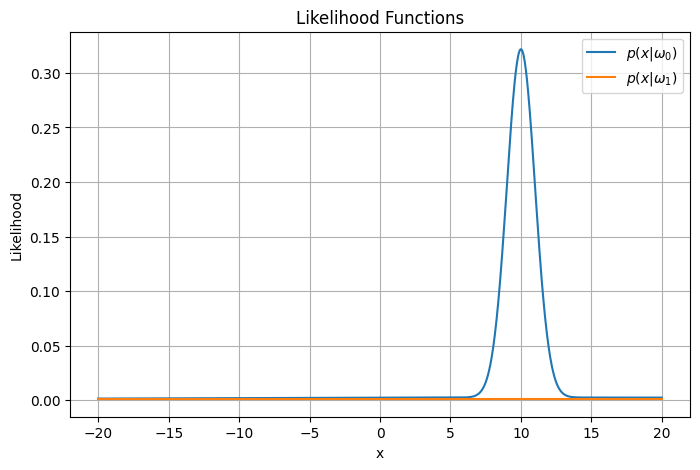

In [2]:
# PRML Lab Assignment 2

# Q1 - Bayesian Decision Theory for Binary Classification

import numpy as np
import matplotlib.pyplot as plt


# Gaussian Probability Density Function
def gaussian(x, mu, sigma):
    """
    Computes Gaussian PDF N(x | mu, sigma^2)
    """
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x - mu)**2 / (2 * sigma**2))


# User Inputs for Class ω0
print("Enter parameters for class ω0")
mu0 = float(input("μ0: "))
sigma0 = float(input("σ0: "))
mu1 = float(input("μ1: "))
sigma1 = float(input("σ1: "))
a = float(input("Mixing coefficient a (0 to 1): "))


# User Inputs for Class ω1
print("\nEnter parameters for class ω1")
mu2 = float(input("μ2: "))
sigma2 = float(input("σ2: "))
mu3 = float(input("μ3: "))
sigma3 = float(input("σ3: "))
b = float(input("Mixing coefficient b (0 to 1): "))


# Define x range
x = np.linspace(-20, 20, 1000)


# Likelihood Functions (Part a)
p_x_w0 = a * gaussian(x, mu0, sigma0) + (1 - a) * gaussian(x, mu1, sigma1)
p_x_w1 = b * gaussian(x, mu2, sigma2) + (1 - b) * gaussian(x, mu3, sigma3)


# Plot Likelihood Functions
plt.figure(figsize=(8, 5))
plt.plot(x, p_x_w0, label=r'$p(x|\omega_0)$')
plt.plot(x, p_x_w1, label=r'$p(x|\omega_1)$')
plt.xlabel("x")
plt.ylabel("Likelihood")
plt.title("Likelihood Functions")
plt.legend()
plt.grid(True)
plt.show()

###Part (b): Posterior Probabilities

Enter prior probability P(ω0): 0.2
Enter prior probability P(ω1): 0.2


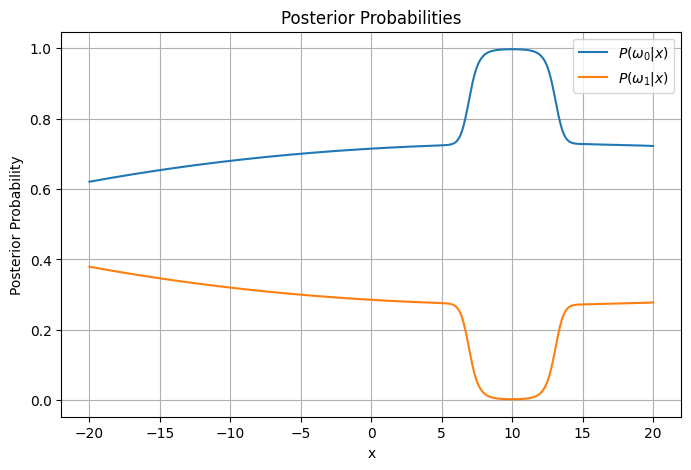

In [8]:
# User Inputs for Prior Probabilities (Part b)
P_w0 = float(input("Enter prior probability P(ω0): "))
P_w1 = float(input("Enter prior probability P(ω1): "))


# Posterior Probabilities using Bayes Rule
p_x = p_x_w0 * P_w0 + p_x_w1 * P_w1

posterior_w0 = (p_x_w0 * P_w0) / p_x
posterior_w1 = (p_x_w1 * P_w1) / p_x


# Plot Posterior Probabilities
plt.figure(figsize=(8, 5))
plt.plot(x, posterior_w0, label=r'$P(\omega_0|x)$')
plt.plot(x, posterior_w1, label=r'$P(\omega_1|x)$')
plt.xlabel("x")
plt.ylabel("Posterior Probability")
plt.title("Posterior Probabilities")
plt.legend()
plt.grid(True)
plt.show()

###Part (c): Likelihood Ratio Test & Minimum Risk Classification Decision

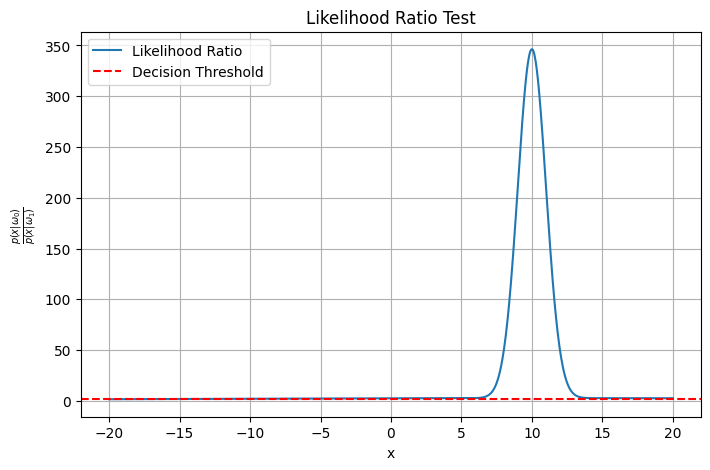

In [5]:
# Likelihood Ratio Test (Part c)
likelihood_ratio = p_x_w0 / p_x_w1
threshold = P_w1 / P_w0


# Plot Likelihood Ratio and Threshold
plt.figure(figsize=(8, 5))
plt.plot(x, likelihood_ratio, label='Likelihood Ratio')
plt.axhline(y=threshold, color='red', linestyle='--', label='Decision Threshold')
plt.xlabel("x")
plt.ylabel(r'$\frac{p(x|\omega_0)}{p(x|\omega_1)}$')
plt.title("Likelihood Ratio Test")
plt.legend()
plt.grid(True)
plt.show()

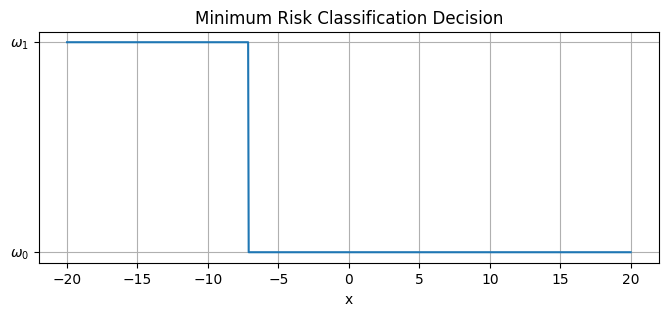

In [6]:
# Minimum Risk Decision Rule (0–1 Loss)
decision = np.where(likelihood_ratio > threshold, 0, 1)

plt.figure(figsize=(8, 3))
plt.plot(x, decision)
plt.yticks([0, 1], [r'$\omega_0$', r'$\omega_1$'])
plt.xlabel("x")
plt.title("Minimum Risk Classification Decision")
plt.grid(True)
plt.show()

### Que 2 Beta Distribution and KL Divergence

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta
from scipy.stats import norm

# Beta PDF
def beta_pdf(x, a, b):
    return (x ** (a - 1) * (1 - x) ** (b - 1)) / (beta(a, b))

# x range
x = np.linspace(0.001, 0.999, 2000)
dx = x[1]-x[0]
eps = 1e-12

### Part (a) Plot Beta PDFs for dfferernt alpha beta's



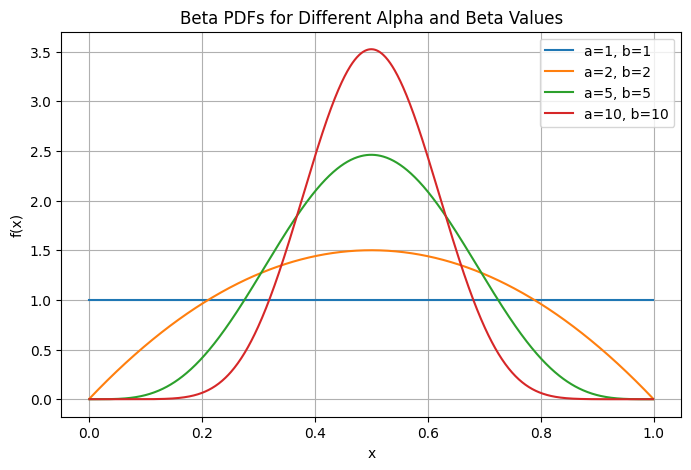

In [6]:
params = [(1,1), (2,2), (5,5), (10,10)]

plt.figure(figsize=(8,5))
for a,b in params:
  plt.plot(x, beta_pdf(x,a,b), label=f'a={a}, b={b}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Beta PDFs for Different Alpha and Beta Values')
plt.legend()
plt.grid(True)
plt.show()

###Part (b) KL Divergence between Beta and Gaussian

In [15]:
alphas = [2,5,10,20,50]
betas = [2,5,10,20,50]

kl_values = []

for a in alphas:
  for b in betas:
    #Beta distribution
    P = beta_pdf(x,a,b)

    #Mean and Variance
    mean = a / (a + b)
    std_dev = np.sqrt(a * b / ((a + b) ** 2 * (a + b + 1)))
    Q = norm.pdf(x, mean, std_dev)

    #Normalize (numerical stability)
    P /= np.sum(P*dx)
    Q /= np.sum(Q*dx)

    kl = np.sum(P * np.log((P+eps) / (Q+eps))* dx)
    kl_values.append((a,b,kl))

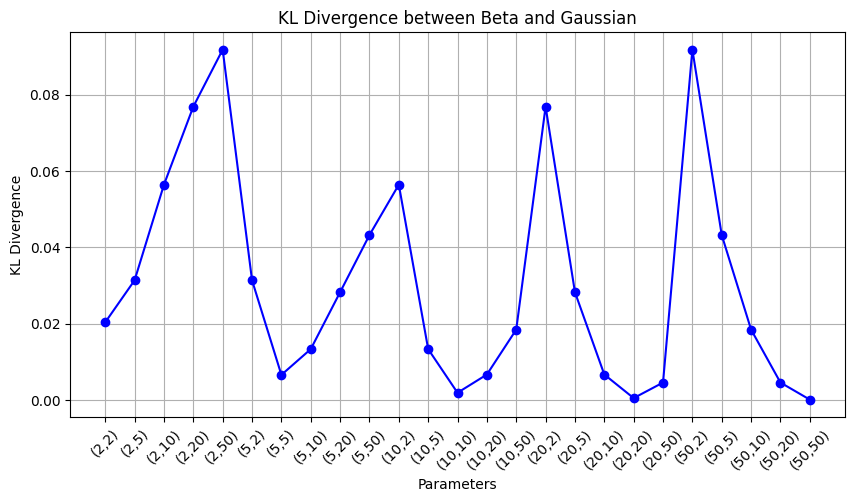

In [16]:
# Plot KL Divergence

plot_labels = [f'({a},{b})' for a,b,_ in kl_values]

# Then, extract just the kl_value component for plotting
kl_plot_data = [kl_val for _,_,kl_val in kl_values]

plt.figure(figsize=(10,5))
plt.plot(plot_labels, kl_plot_data, marker='o', linestyle='-', color='b') # Use the extracted kl_plot_data here
plt.xlabel('Parameters')
plt.ylabel('KL Divergence')
plt.title('KL Divergence between Beta and Gaussian')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

###Question 3: Diagonal Sort Decreasing

In [21]:
from collections import defaultdict

#Taking matrix dimensions as input

N = int(input("Enter the number of rows (N): "))
M = int(input("Enter the number of columns (M):"))

#Matrix elements as input

print("Enter the elements of the matrix row-wise:")
matrix = []
for i in range(N):
  row = list(map(int, input(f"Row {i+1}: ").split()))
  matrix.append(row)


# Function to sort diagonals in decreasing order

def sort_diagonals(matrix):
  diagonals = defaultdict(list)
  n = len(matrix)
  m = len(matrix[0])

  for i in range(n):
    for j in range(m):
      diagonals[i-j].append(matrix[i][j])

  for diagonal in diagonals:
    diagonals[diagonal].sort(reverse=True)

  for i in range(n):
    for j in range(m):
      matrix[i][j] = diagonals[i-j].pop(0)

  return matrix

#Apply diagonal sort
sorted_matrix = sort_diagonals(matrix)

#Print the sorted matrix
print("Sorted Matrix in decreasing order:")
for row in sorted_matrix:
  print(row)

Enter the number of rows (N): 3
Enter the number of columns (M):4
Enter the elements of the matrix row-wise:
Row 1: 3 3 1 1
Row 2: 2 2 1 2
Row 3: 1 1 1 2
Sorted Matrix in decreasing order:
[3, 3, 2, 1]
[2, 2, 2, 1]
[1, 1, 1, 1]


###Question 4: H-Index Problem

In [22]:
# Taking number of papers
n = int(input("Enter the number of papers: "))

# Taking citations as input
citations = list(map(int, input("Enter the citations separated by spaces: ").split()))

#Sort citations in decreasing order
citations.sort(reverse=True)

# Find the h-index
h_index = 0
for i in range(n):
  if citations[i] >= i + 1:
    h_index = i + 1
  else:
    break

#output
print("H-Index", h_index)

Enter the number of papers: 5
Enter the citations separated by spaces: 3 0 6 1 5
H-Index 3
